<a href="https://colab.research.google.com/github/akashsutar21/customer-segmentation-hierarchical-clustering/blob/main/Agglomerative_Hierarchical_Clustering_Mall_Customers_Segmentation_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # Agglomerative_Hierarchical_Clustering_Mall_Customers_Categorization
# Dataset--
hierarchical-clustering-with-python-and-scikit-learn-shopping-data.csv

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline

In [3]:
customer_data=pd.read_csv('/content/hierarchical-clustering-with-python-and-scikit-learn-shopping-data.csv')

In [6]:
customer_data.shape

(200, 5)

In [8]:
customer_data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [11]:
data=customer_data.iloc[:,3:5].values  #Here we take only the Annual income and the Spending score columns only
data

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

# Next step-we will find dendrogram using Scipy library

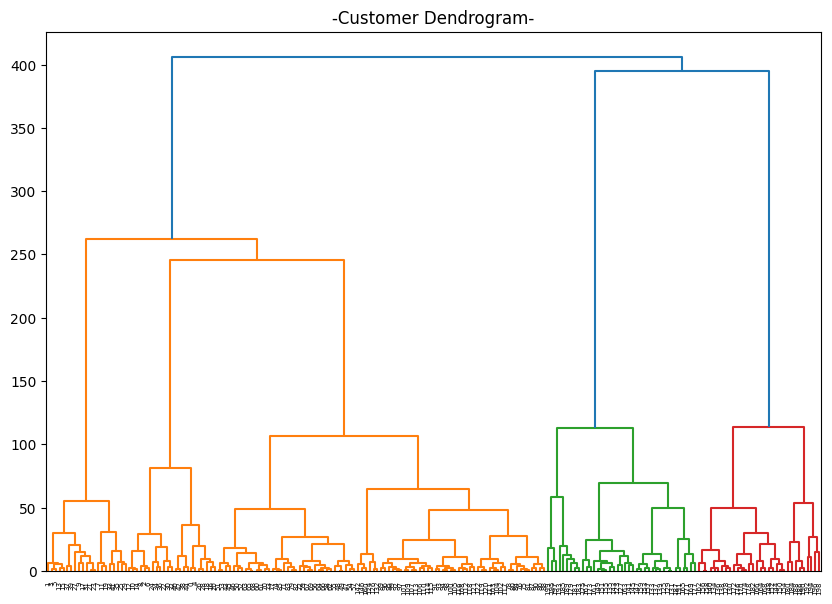

In [14]:
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10,7))
plt.title("-Customer Dendrogram-")
dend=shc.dendrogram(shc.linkage(data,method='ward'))  #here we given the "WARD" linkage to plot the dendrogram. because ward linkage is most efficient

In [18]:
from sklearn.cluster import AgglomerativeClustering

cluster=AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward') #From the dendrogram
#the cluster we take is 5
labels_=cluster.fit_predict(data)

In [20]:
labels_

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

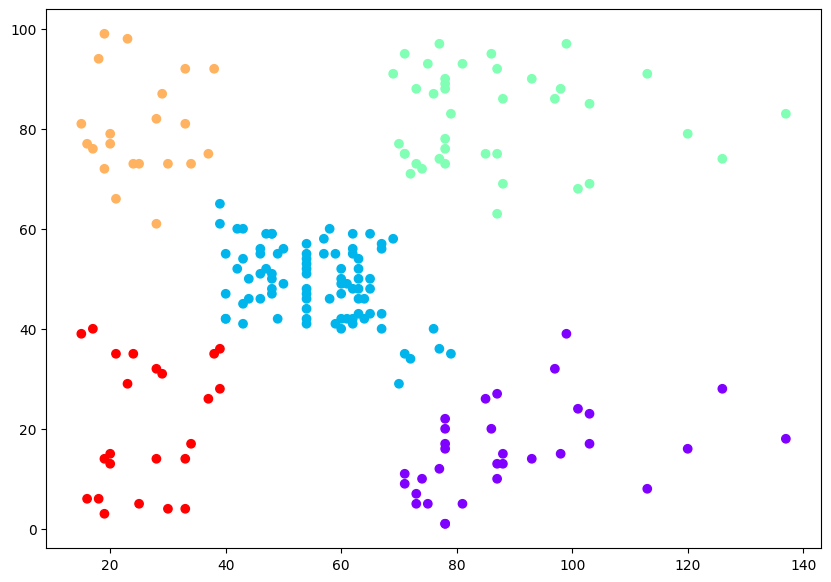

In [23]:
plt.figure(figsize=(10,7))
plt.scatter(data[:,0],data[:,1],c=cluster.labels_,cmap='rainbow')

In [28]:
customer_data['cluster']=labels_   #See which customer is in which cluster
customer_data

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,2
196,197,Female,45,126,28,0
197,198,Male,32,126,74,2
198,199,Male,32,137,18,0


In [30]:
customer_data[customer_data['cluster']==0]   #See the customers are in 0 No cluster

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
128,129,Male,59,71,11,0
130,131,Male,47,71,9,0
134,135,Male,20,73,5,0
136,137,Female,44,73,7,0
138,139,Male,19,74,10,0
140,141,Female,57,75,5,0
144,145,Male,25,77,12,0
148,149,Female,34,78,22,0
150,151,Male,43,78,17,0
152,153,Female,44,78,20,0


In [33]:
#Count customers in each cluster

customer_data['cluster'].value_counts()


,count
cluster,
1,85
2,39
0,32
4,23
3,21


In [37]:
customer_data['Cluster'] = labels_
#Create a new column named Cluster in the customer_data DataFrame and store the cluster
# label of each customer in that column.

In [41]:
cluster_summary = customer_data.groupby('Cluster').mean(numeric_only=True).round()
print(cluster_summary)

         CustomerID   Age  Annual Income (k$)  Spending Score (1-100)  cluster
Cluster                                                                       
0             166.0  41.0                89.0                    16.0      0.0
1              88.0  42.0                56.0                    49.0      1.0
2             162.0  33.0                87.0                    82.0      2.0
3              22.0  25.0                25.0                    80.0      3.0
4              23.0  45.0                26.0                    21.0      4.0


# Giving the customers business names

In [50]:
#Catagorized the cutomers by business names accrodingly to their spending

cluster_names={
    0:'Wealthy but careful customers',
    1:'Average customers',
    2:'Premium customers',
    3:'High-spending customers',
    4:'Budget customers'
}

customer_data['Customer_Type']=customer_data['cluster'].map(cluster_names)

In [52]:
#Then print 10 same customer data with business names
customer_data[['Annual Income (k$)',
               'Spending Score (1-100)',
                'CustomerID',
               'cluster',
               'Customer_Type']].head(10)

,Annual Income (k$),Spending Score (1-100),CustomerID,cluster,Customer_Type
0,15,39,1,4,Budget customers
1,15,81,2,3,High-spending customers
2,16,6,3,4,Budget customers
3,16,77,4,3,High-spending customers
4,17,40,5,4,Budget customers
5,17,76,6,3,High-spending customers
6,18,6,7,4,Budget customers
7,18,94,8,3,High-spending customers
8,19,3,9,4,Budget customers
9,19,72,10,3,High-spending customers
